# EX 1 — Three-Layer Neural Network From Scratch

**AI23531 Deep Learning Lab — Individual Experiment**

The code and the output below are preserved from the uploaded `Copy_of_deep_learning_lab.ipynb`.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1, Loss: 1.8860
Epoch 2, Loss: 0.8789
Epoch 3, Loss: 0.6006
Epoch 4, Loss: 0.4886
Epoch 5, Loss: 0.4309
Epoch 6, Loss: 0.3948
Epoch 7, Loss: 0.3685
Epoch 8, Loss: 0.3479
Epoch 9, Loss: 0.3305
Epoch 10, Loss: 0.3163


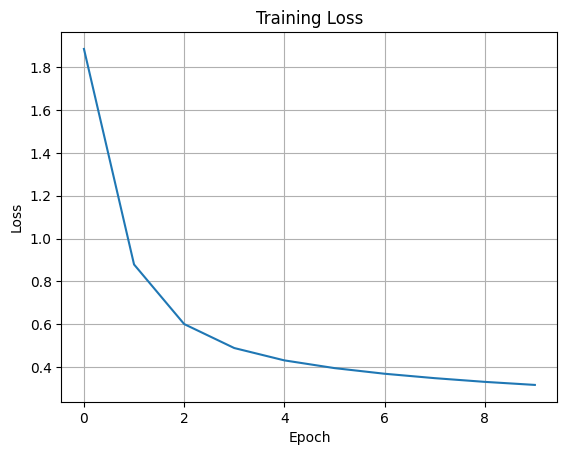

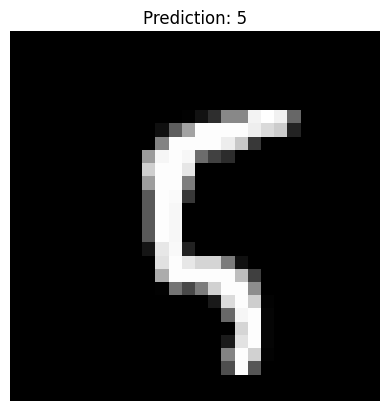

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder

(X_train_raw, y_train_raw), (_, _) = mnist.load_data()

X_train_images = X_train_raw.copy()

X_train = X_train_raw.reshape(-1, 784) / 255.0

try:
    encoder = OneHotEncoder(sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(sparse=False)
y_train = encoder.fit_transform(y_train_raw.reshape(-1, 1))

input_size, hidden_size, output_size = 784, 64, 10
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

sigmoid = lambda x: 1 / (1 + np.exp(-x))
sigmoid_deriv = lambda a: a * (1 - a)
loss_fn = lambda y, y_hat: -np.mean(np.sum(y * np.log(y_hat + 1e-8), axis=1))

epochs, lr, batch_size = 10, 0.1, 128
n_samples = X_train.shape[0]
losses = []

for epoch in range(epochs):
    perm = np.random.permutation(n_samples)
    X_shuffled = X_train[perm]
    y_shuffled = y_train[perm]

    total_loss = 0.0
    n_batches = 0

    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        x = X_shuffled[start:end]
        y = y_shuffled[start:end]

        z1 = x @ W1 + b1
        a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        loss = loss_fn(y, a2)
        total_loss += loss
        n_batches += 1

        m = x.shape[0]
        dz2 = (a2 - y) / m
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        dz1 = (dz2 @ W2.T) * sigmoid_deriv(a1)
        dW1 = x.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    losses.append(total_loss / n_batches)
    print(f"Epoch {epoch + 1}, Loss: {losses[-1]:.4f}")

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

def predict(img_raw):
    """img_raw: a single unnormalized 28x28 image (0-255 pixel values)."""
    img = img_raw.reshape(1, 784) / 255.0
    a1 = sigmoid(img @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)
    return np.argmax(a2)

idx = 100
plt.imshow(X_train_images[idx], cmap='gray')
plt.title(f"Prediction: {predict(X_train_images[idx])}")
plt.axis('off')
plt.show()